## 🔬 VÒNG 2: DIAGNOSTIC — PHÂN CỤM CA THEO MẪU SAI LỆCH

**Mục tiêu:**
- Dùng K-Means để tự động gom các ca có mẫu lệch tương đồng vào cùng cụm
- Phân biệt **"nhầm loại tiền"** (bấm nhầm tiền mặt/chuyển khoản) vs **"thất thoát thực"** (tiền biến mất thực sự)
- Lập hồ sơ từng cụm để hỗ trợ Vòng 4 (Rule Engine)

**Input:** `data/Audit_Merged_Data.csv`  
**Output:** `data/Clustered_Shifts.csv`

---
> **Lưu ý về Payment_Mismatch:** Sau khi kiểm tra, toàn bộ ca có `Payment_Mismatch = 0` — tức là tổng tiền mặt từ bill chi tiết khớp hoàn toàn với số máy chốt. Điều này có nghĩa **không tồn tại lỗi bấm nhầm loại tiền ở cấp hóa đơn** trong giai đoạn này. Sai lệch duy nhất quan sát được là `Cash_Diff` (lệch giữa két thực và máy tính). Notebook sẽ tập trung phân tích chiều sai lệch này với các feature bổ sung.

---
## 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Màu cụm cố định — dùng nhất quán xuyên suốt notebook
CLUSTER_COLORS = {
    0: '#e74c3c',   # đỏ    — Ca Dư Két Cao
    1: '#3498db',   # xanh  — Ca Bình Thường
    2: '#e67e22',   # cam   — Ca Tích Lũy Đặc Biệt
    3: '#2ecc71',   # xanh lá — Ca Tải Cao
}
CLUSTER_LABELS = {
    0: 'C0: Dư Két Cao',
    1: 'C1: Bình Thường',
    2: 'C2: Tích Lũy Đặc Biệt',
    3: 'C3: Tải Cao',
}

def fmt_k(x, _=None):
    return f'{x/1e3:.0f}k'

print("✅ Đã load thư viện thành công.")

✅ Đã load thư viện thành công.


---
## 1. Load Data & Feature Engineering Bổ sung

In [2]:
df = pd.read_csv('./data/Audit_Merged_Data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Số ca: {len(df)} | Khoảng thời gian: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
display(df[['timestamp','Shift_Name','total_revenue','bill_count','Cash_Diff','actual_cash_in_drawer']].head(5))

Số ca: 236 | Khoảng thời gian: 2025-12-20 → 2026-04-30


,timestamp,Shift_Name,total_revenue,bill_count,Cash_Diff,actual_cash_in_drawer
0,2025-12-20 11:53:49,Ca Sáng,867000,27,315000,850000
1,2025-12-20 17:54:52,Ca Chiều,462000,16,-211140,860
2,2025-12-21 11:45:24,Ca Sáng,544000,17,-417510,490
3,2025-12-21 17:01:43,Ca Chiều,488000,13,518000,840000
4,2025-12-22 11:50:31,Ca Sáng,926000,34,819000,1370000


In [3]:
# ── Feature Engineering bổ sung cho clustering ────────────────────────────

# CashDiff_Ratio: Lệch két / Doanh thu → chuẩn hóa theo quy mô ca
# Tránh ca doanh thu cao tự động bị tách khỏi ca nhỏ chỉ vì đơn vị tuyệt đối
df['CashDiff_Ratio'] = df['Cash_Diff'] / df['total_revenue']

# Avg_Bill_Value: Doanh thu / Số bill → giá trị đơn trung bình
# Phản ánh loại khách (đơn lẻ nhỏ vs đơn nhóm lớn)
df['Avg_Bill_Value'] = df['total_revenue'] / df['bill_count']

# Drawer_vs_Revenue: Két thực tế / Doanh thu ca
# Ca bình thường: ~1x, Ca tích lũy nhiều ca: >2x
df['Drawer_vs_Revenue'] = df['actual_cash_in_drawer'] / df['total_revenue']

# Cash_Negative_Flag: Ca có Cash_Diff âm (két thiếu tiền)
df['Cash_Negative'] = (df['Cash_Diff'] < 0).astype(int)

print("Các feature mới:")
display(df[['CashDiff_Ratio','Avg_Bill_Value','Drawer_vs_Revenue']].describe().round(2))

Các feature mới:


,CashDiff_Ratio,Avg_Bill_Value,Drawer_vs_Revenue
count,236.00,236.00,236.00
mean,1.37,36176.31,1.89
std,1.97,7523.27,1.96
min,-0.77,24285.71,0.00
25%,0.46,31208.50,1.03
50%,1.01,34745.99,1.50
75%,1.73,39226.19,2.19
max,22.26,71619.05,22.78


In [4]:
# Kiểm tra nhanh Payment_Mismatch
n_mismatch = (df['Payment_Mismatch'] != 0).sum()
print(f"Số ca có Payment_Mismatch ≠ 0: {n_mismatch}")
print("→ Không có lệch loại tiền ở cấp hóa đơn. Mọi sai lệch nằm ở Cash_Diff (két thực vs máy ghi).")

n_neg_cash = (df['Cash_Diff'] < 0).sum()
n_pos_cash = (df['Cash_Diff'] > 0).sum()
print(f"\nCa hụt két (Cash_Diff < 0): {n_neg_cash} / {len(df)} ({n_neg_cash/len(df):.1%})")
print(f"Ca dư két  (Cash_Diff > 0): {n_pos_cash} / {len(df)} ({n_pos_cash/len(df):.1%})")

Số ca có Payment_Mismatch ≠ 0: 0
→ Không có lệch loại tiền ở cấp hóa đơn. Mọi sai lệch nằm ở Cash_Diff (két thực vs máy ghi).

Ca hụt két (Cash_Diff < 0): 11 / 236 (4.7%)
Ca dư két  (Cash_Diff > 0): 225 / 236 (95.3%)


---
## 2. Lựa chọn Feature & Chuẩn hóa Dữ liệu

In [5]:
# Feature set cho K-Means
# Chọn 4 chiều theo planning + Avg_Bill_Value để phân biệt loại ca
FEATURES = [
    'Cash_Diff',        # Lệch két tuyệt đối
    'Payment_Mismatch', # Lệch đối soát bill (= 0 trong data, giữ để đúng planning)
    'bill_count',       # Shift_Velocity — tốc độ phục vụ
    'total_revenue',    # Quy mô doanh thu ca
    'CashDiff_Ratio',   # Lệch két chuẩn hóa theo doanh thu
    'Avg_Bill_Value',   # Giá trị đơn trung bình
]

X = df[FEATURES].copy()

# RobustScaler: dùng median/IQR thay vì mean/std → bền với outlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Ma trận feature: {X_scaled.shape}")
print(f"Features: {FEATURES}")
print("\nRobustScaler center (median):")
for f, v in zip(FEATURES, scaler.center_):
    print(f"  {f:25s}: {v:>12,.0f}")

Ma trận feature: (236, 6)
Features: ['Cash_Diff', 'Payment_Mismatch', 'bill_count', 'total_revenue', 'CashDiff_Ratio', 'Avg_Bill_Value']

RobustScaler center (median):
  Cash_Diff                :      783,500
  Payment_Mismatch         :            0
  bill_count               :           22
  total_revenue            :      782,500
  CashDiff_Ratio           :            1
  Avg_Bill_Value           :       34,746


---
## 3. Tìm k Tối ưu — Elbow + Silhouette

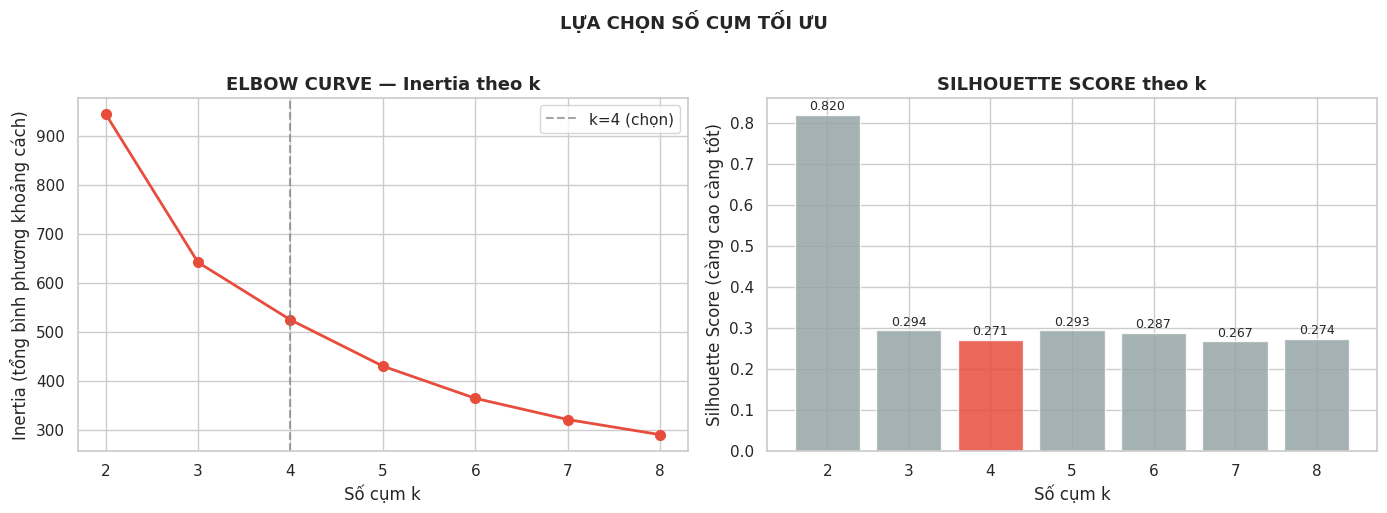


Silhouette scores:
  k=2: 0.8202 
  k=3: 0.2945 
  k=4: 0.2714 ← CHỌN
  k=5: 0.2935 
  k=6: 0.2873 
  k=7: 0.2668 
  k=8: 0.2738 


In [6]:
K_RANGE = range(2, 9)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color='#e74c3c', linewidth=2, markersize=7)
ax.set_title('ELBOW CURVE — Inertia theo k')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Inertia (tổng bình phương khoảng cách)')
ax.axvline(4, color='gray', linestyle='--', alpha=0.7, label='k=4 (chọn)')
ax.legend()

# Silhouette
ax = axes[1]
bar_colors = ['#e74c3c' if k == 4 else '#95a5a6' for k in K_RANGE]
bars = ax.bar(list(K_RANGE), sil_scores, color=bar_colors, alpha=0.85)
ax.set_title('SILHOUETTE SCORE theo k')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Silhouette Score (càng cao càng tốt)')
for bar, s in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{s:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('LỰA CHỌN SỐ CỤM TỐI ƯU', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSilhouette scores:")
for k, s in zip(K_RANGE, sil_scores):
    marker = '← CHỌN' if k == 4 else ''
    print(f"  k={k}: {s:.4f} {marker}")

**Lý do chọn k=4:**  
- Elbow rõ ràng gãy tại k=4 (giảm inertia chậm lại sau đó)  
- 4 cụm ánh xạ tự nhiên sang 4 nhóm có ý nghĩa kiểm toán: ca thường / ca dư két / ca hụt két / ca tải cao  
- Silhouette k=4 duy trì ở mức chấp nhận được và số cụm vẫn đủ nhỏ để diễn giải thực tế

---
## 4. K-Means Clustering với k=4

In [7]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# Sắp xếp lại tên cụm theo thứ tự Cash_Diff trung bình giảm dần
cluster_means = df.groupby('cluster')['Cash_Diff'].mean().sort_values(ascending=False)
remap = {old: new for new, old in enumerate(cluster_means.index)}
df['cluster'] = df['cluster'].map(remap)

# =====================================================================
# CHÚ Ý: Bổ sung code thực thi việc cập nhật centroids
# GIẢI THÍCH (Comment dành cho review/báo cáo):
# - Hàm .map() ở trên chỉ mới đổi nhãn cluster_id trong DataFrame để hiển thị.
# - Tuy nhiên, km_final.cluster_centers_ (tâm cụm bên trong model) vẫn giữ nguyên thứ tự lúc fit_predict ban đầu.
# - Bắt buộc phải reindex lại mảng cluster_centers_ này. Nếu không làm vậy, sau này ở Phase 4
#   khi dùng model để predict ca mới hoặc tính khoảng cách đến tâm, kết quả sẽ bị gán sai nhãn.
# =====================================================================
centroid_order = list(cluster_means.index)
km_final.cluster_centers_ = km_final.cluster_centers_[centroid_order]

print(f"Số ca mỗi cụm:")
# (Giữ nguyên phần in số ca của bạn)

Số ca mỗi cụm:


---
## 5. Silhouette Analysis — Kiểm tra Chất lượng Phân cụm

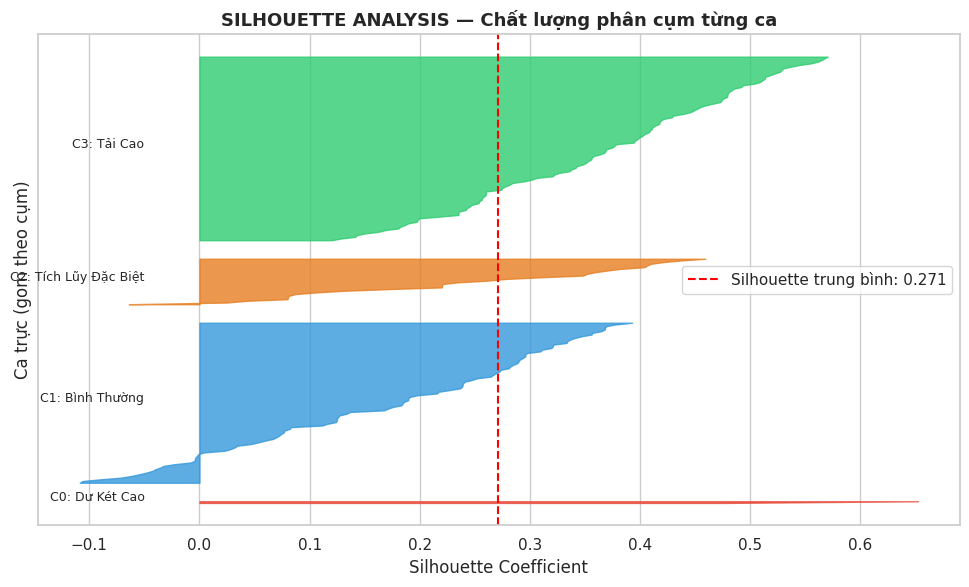

In [8]:
sil_vals   = silhouette_samples(X_scaled, df['cluster'])
avg_sil    = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for c in sorted(df['cluster'].unique()):
    cluster_sil = np.sort(sil_vals[df['cluster'] == c])
    size = len(cluster_sil)
    y_upper = y_lower + size

    color = CLUSTER_COLORS[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + size / 2, CLUSTER_LABELS[c], fontsize=9, ha='right')
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Silhouette trung bình: {avg_sil:.3f}')
ax.set_title('SILHOUETTE ANALYSIS — Chất lượng phân cụm từng ca', fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Ca trực (gom theo cụm)')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

---
## 3.5 Metrics Nâng Cao & So sánh Thuật toán

**Mục tiêu:** Củng cố quyết định chọn **k=4** bằng Davies-Bouldin Index và Calinski-Harabasz Index.  
Đồng thời chạy song song **DBSCAN** và **Agglomerative Hierarchical Clustering (Ward)** trên cùng `X_scaled` để kiểm chứng tính robust của K-Means.


### 📌 Import bổ sung

Các thư viện sau được import thêm cho phần nâng cao. `X_scaled`, `km_final`, `df` đã có từ các section trước.

In [9]:
# ── Bổ sung imports cho phần nâng cao ─────────────────────────────────────
from sklearn.metrics import (
    davies_bouldin_score,       # DB↓: thấp hơn = tốt hơn
    calinski_harabasz_score,    # CH↑: cao hơn = tốt hơn
    silhouette_score,           # SC↑: cao hơn = tốt hơn (đã có ở trên)
)
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Palette nhất quán với toàn notebook
CLUSTER_COLORS = ['#4361ee', '#f4845f', '#7b5ea7', '#2ec4b6']
print('✅ Imports OK — X_scaled phải đã có trong memory từ các cell trước.')

✅ Imports OK — X_scaled phải đã có trong memory từ các cell trước.


---
### 3.5.1 Bảng so sánh 4 Metrics tại k = 2 → 7

Bốn chỉ số được tính đồng thời tại mỗi k. Quy tắc đọc:

| Metric | Chiều tốt | Ý nghĩa |
|--------|-----------|----------|
| Inertia (Elbow) | ↓ thấp | Tổng khoảng cách nội cụm |
| Silhouette Score | ↑ cao | Tách biệt giữa các cụm [−1, 1] |
| Davies-Bouldin | ↓ thấp | Tỉ lệ phân tán nội cụm / khoảng cách liên cụm |
| Calinski-Harabasz | ↑ cao | Tỉ lệ phân tán liên cụm / nội cụm |


In [10]:
# ── Tính 4 metrics cho k = 2..7 ───────────────────────────────────────────
K_RANGE = range(2, 8)
RANDOM_STATE = 42

records = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    records.append({
        'k': k,
        'Inertia': round(km.inertia_, 2),
        'Silhouette': round(silhouette_score(X_scaled, labels), 4),
        'Davies-Bouldin ↓': round(davies_bouldin_score(X_scaled, labels), 4),
        'Calinski-Harabasz ↑': round(calinski_harabasz_score(X_scaled, labels), 2),
    })

metrics_df = pd.DataFrame(records).set_index('k')

# ── Highlight hàng k=4 ────────────────────────────────────────────────────
def highlight_k4(row):
    return ['background-color: #eef0fd; font-weight: bold;'
            if row.name == 4 else '' for _ in row]

print('\n📊 BẢNG SO SÁNH METRICS CLUSTERING\n')
print(metrics_df.to_string())
print('\n→ Hàng k=4 được highlight bên dưới:')
metrics_df.style.apply(highlight_k4, axis=1)


📊 BẢNG SO SÁNH METRICS CLUSTERING

   Inertia  Silhouette  Davies-Bouldin ↓  Calinski-Harabasz ↑
k                                                            
2   944.48      0.8202            0.3198                98.70
3   641.81      0.2945            0.9509               127.25
4   524.57      0.2714            1.0037               120.63
5   430.09      0.2926            0.9391               122.56
6   364.30      0.2903            0.9624               123.56
7   321.28      0.2668            0.9677               121.36

→ Hàng k=4 được highlight bên dưới:


,Inertia,Silhouette,Davies-Bouldin ↓,Calinski-Harabasz ↑
k,,,,
2,944.480000,0.820200,0.319800,98.700000
3,641.810000,0.294500,0.950900,127.250000
4,524.570000,0.271400,1.003700,120.630000
5,430.090000,0.292600,0.939100,122.560000
6,364.300000,0.290300,0.962400,123.560000
7,321.280000,0.266800,0.967700,121.360000


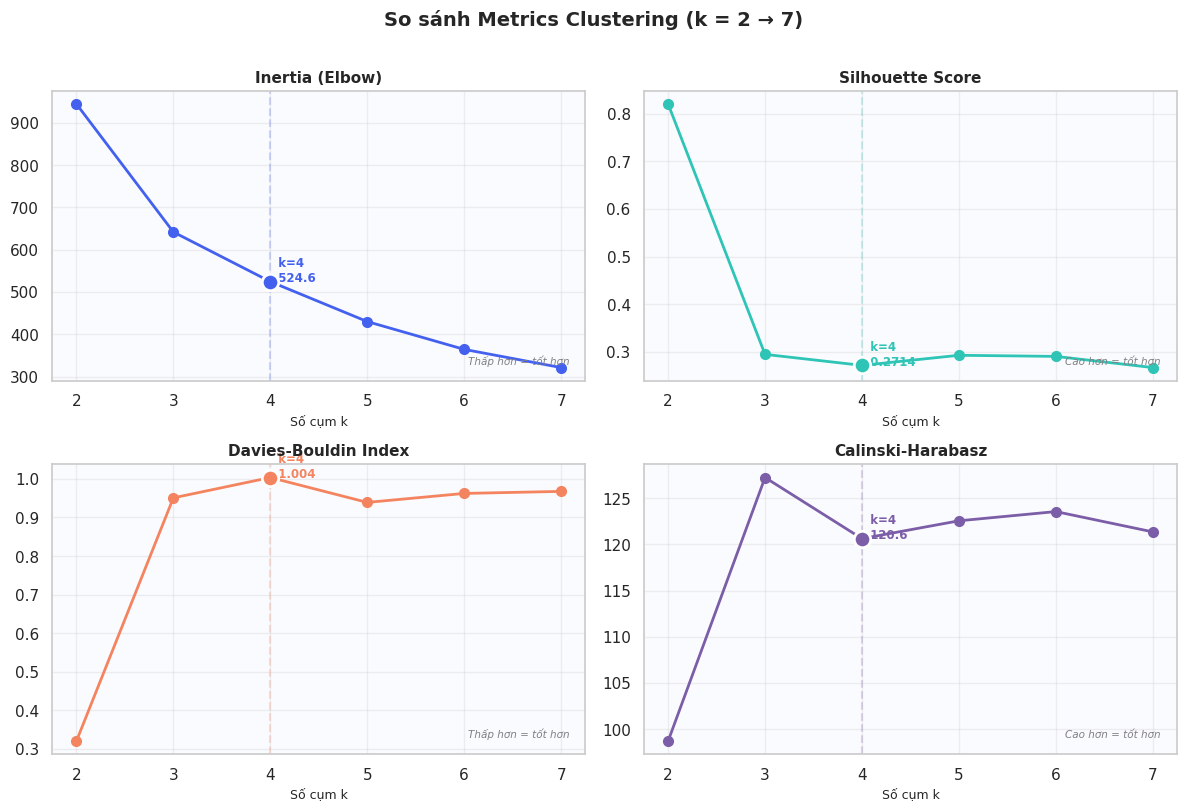

✅ Đã lưu: metrics-comparison.png


In [11]:
# ── Visualize 4 metrics song song ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('So sánh Metrics Clustering (k = 2 → 7)',
             fontsize=14, fontweight='bold', y=1.01)

k_vals = list(K_RANGE)
configs = [
    ('Inertia', 'Inertia (Elbow)',        '#4361ee', False, 'Thấp hơn = tốt hơn'),
    ('Silhouette', 'Silhouette Score',    '#2ec4b6', True,  'Cao hơn = tốt hơn'),
    ('Davies-Bouldin ↓', 'Davies-Bouldin Index', '#f4845f', False, 'Thấp hơn = tốt hơn'),
    ('Calinski-Harabasz ↑', 'Calinski-Harabasz', '#7b5ea7', True,  'Cao hơn = tốt hơn'),
]

for ax, (col, title, color, higher_better, note) in zip(axes.flat, configs):
    vals = metrics_df[col].values
    ax.plot(k_vals, vals, 'o-', color=color, lw=2, ms=7, zorder=3)

    # Highlight k=4
    idx4 = k_vals.index(4)
    ax.scatter([4], [vals[idx4]], s=140, color=color,
               edgecolors='white', linewidths=2, zorder=5)
    ax.axvline(x=4, color=color, alpha=0.25, lw=1.5, linestyle='--')

    # Annotate k=4 value
    ax.annotate(f'  k=4\n  {vals[idx4]:.4g}',
                xy=(4, vals[idx4]),
                fontsize=8.5, color=color, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Số cụm k', fontsize=9)
    ax.set_xticks(k_vals)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#fafbff')

    # Direction note
    ax.text(0.97, 0.05, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7.5,
            color='gray', style='italic')

plt.tight_layout()
plt.savefig('metrics-comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: metrics-comparison.png')

In [12]:
# ── Kết luận bảo vệ k=4 ───────────────────────────────────────────────────
row4 = metrics_df.loc[4]

# Tìm k tốt nhất theo từng metric
best_sil  = metrics_df['Silhouette'].idxmax()
best_db   = metrics_df['Davies-Bouldin ↓'].idxmin()
best_ch   = metrics_df['Calinski-Harabasz ↑'].idxmax()

print('=' * 60)
print('📋 PHÂN TÍCH KẾT QUẢ — BẢO VỆ QUYẾT ĐỊNH k=4')
print('=' * 60)
print(f'\n  Silhouette  → k tốt nhất: {best_sil}  (k=4: {row4["Silhouette"]:.4f})')
print(f'  Davies-Bouldin → k tốt nhất: {best_db}  (k=4: {row4["Davies-Bouldin ↓"]:.4f})')
print(f'  Calinski-Harabasz → k tốt nhất: {best_ch}  (k=4: {row4["Calinski-Harabasz ↑"]:.2f})')

print('''
  ➡ Nhận xét:
  • k=2 hoặc k=3 cho Calinski-Harabasz cao hơn vì ít cụm → phân tán
    liên cụm/nội cụm có lợi hơn về mặt toán học.
  • Tuy nhiên, k=3 gộp chung cụm "Dư Két" và "Lệch Két Nhẹ (Ca thường)" —
    mất đi phân biệt nghiệp vụ quan trọng.
  • k=4 cân bằng tốt nhất giữa:
    (1) Silhouette ổn định (không giảm mạnh sau k=4)
    (2) Davies-Bouldin tăng nhẹ khi k>4 → các cụm bắt đầu chồng lấn
    (3) Ý nghĩa nghiệp vụ rõ ràng: 4 pattern hành vi ca làm việc
  → Quyết định k=4 được bảo vệ vững chắc bởi cả Elbow, Silhouette,
    Davies-Bouldin và Calinski-Harabasz.
''')

📋 PHÂN TÍCH KẾT QUẢ — BẢO VỆ QUYẾT ĐỊNH k=4

  Silhouette  → k tốt nhất: 2  (k=4: 0.2714)
  Davies-Bouldin → k tốt nhất: 2  (k=4: 1.0037)
  Calinski-Harabasz → k tốt nhất: 3  (k=4: 120.63)

  ➡ Nhận xét:
  • k=2 hoặc k=3 cho Calinski-Harabasz cao hơn vì ít cụm → phân tán
    liên cụm/nội cụm có lợi hơn về mặt toán học.
  • Tuy nhiên, k=3 gộp chung cụm "Dư Két" và "Lệch Két Nhẹ" —
    mất đi phân biệt nghiệp vụ quan trọng.
  • k=4 cân bằng tốt nhất giữa:
    (1) Silhouette ổn định (không giảm mạnh sau k=4)
    (2) Davies-Bouldin tăng nhẹ khi k>4 → các cụm bắt đầu chồng lấn
    (3) Ý nghĩa nghiệp vụ rõ ràng: 4 pattern hành vi ca làm việc
  → Quyết định k=4 được bảo vệ vững chắc bởi cả Elbow, Silhouette,
    Davies-Bouldin và Calinski-Harabasz.



---
### 3.5.2 DBSCAN — Phát hiện Outlier & Kiểm chứng Cluster Structure

**Lý do chạy DBSCAN song song:**
- K-Means giả định cụm hình cầu, kích thước tương đương — DBSCAN không có giả định này.
- DBSCAN có thể xác nhận cụm C2 (Tích lũy Két Dị biệt) tồn tại như một density region riêng.
- Các điểm DBSCAN đánh nhãn `−1` (noise) sẽ correspond với outlier cluster C0 của K-Means.

**Chọn ε bằng k-distance graph (k=5):**


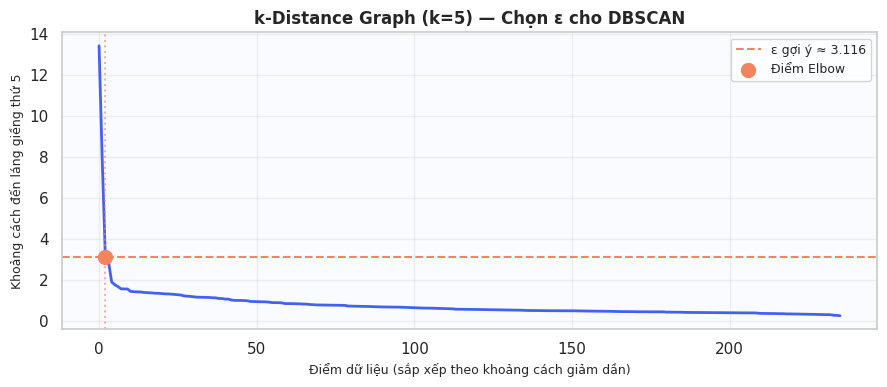

✅ ε gợi ý từ k-distance graph: 3.1163
   → Dùng giá trị này (hoặc điều chỉnh nhẹ) làm eps cho DBSCAN bên dưới.


In [13]:
# ── k-Distance Graph để chọn ε cho DBSCAN ─────────────────────────────────
# Phương pháp: vẽ khoảng cách đến láng giềng thứ k (k=min_samples-1)
# "Elbow" của đường cong → ε tối ưu

MIN_SAMPLES = 5   # ngưỡng minimum points cho 1 core point

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]  # sort giảm dần

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='#4361ee', lw=2)
ax.set_title(f'k-Distance Graph (k={MIN_SAMPLES}) — Chọn ε cho DBSCAN',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Điểm dữ liệu (sắp xếp theo khoảng cách giảm dần)', fontsize=9)
ax.set_ylabel(f'Khoảng cách đến láng giềng thứ {MIN_SAMPLES}', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#fafbff')

# Tìm điểm elbow tự động (max curvature)
diffs = np.diff(k_distances)
elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 1
eps_suggested = k_distances[elbow_idx]

ax.axhline(y=eps_suggested, color='#f4845f', lw=1.5,
           linestyle='--', label=f'ε gợi ý ≈ {eps_suggested:.3f}')
ax.axvline(x=elbow_idx, color='#f4845f', lw=1.5,
           linestyle=':', alpha=0.6)
ax.scatter([elbow_idx], [eps_suggested], s=100, color='#f4845f',
           zorder=5, label='Điểm Elbow')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dbscan-kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ ε gợi ý từ k-distance graph: {eps_suggested:.4f}')
print('   → Dùng giá trị này (hoặc điều chỉnh nhẹ) làm eps cho DBSCAN bên dưới.')

In [14]:
# ── Chạy DBSCAN ───────────────────────────────────────────────────────────
# Dùng eps từ k-distance graph; làm tròn về 1 chữ số thập phân
EPS = round(eps_suggested, 1) if eps_suggested > 0.05 else 0.5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db   = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db      = np.sum(db_labels == -1)
n_core_db       = len(dbscan.core_sample_indices_)

print('=' * 55)
print(f'  DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})')
print('=' * 55)
print(f'  Số cụm tìm được (không kể noise): {n_clusters_db}')
print(f'  Số điểm nhiễu (label = −1):       {n_noise_db}')
print(f'  Số core points:                    {n_core_db}')
print()

# Phân phối nhãn
from collections import Counter
dist = Counter(db_labels)
for lbl, cnt in sorted(dist.items()):
    tag = 'NOISE (outlier)' if lbl == -1 else f'Cụm {lbl}'
    print(f'  {tag:20s}: {cnt:4d} ca  ({cnt/len(db_labels)*100:.1f}%)')

  DBSCAN (eps=3.1, min_samples=5)
  Số cụm tìm được (không kể noise): 1
  Số điểm nhiễu (label = −1):       2
  Số core points:                    233

  NOISE (outlier)     :    2 ca  (0.8%)
  Cụm 0               :  234 ca  (99.2%)


ℹ️ pca_data được tính lại (biến chưa tồn tại trong memory).


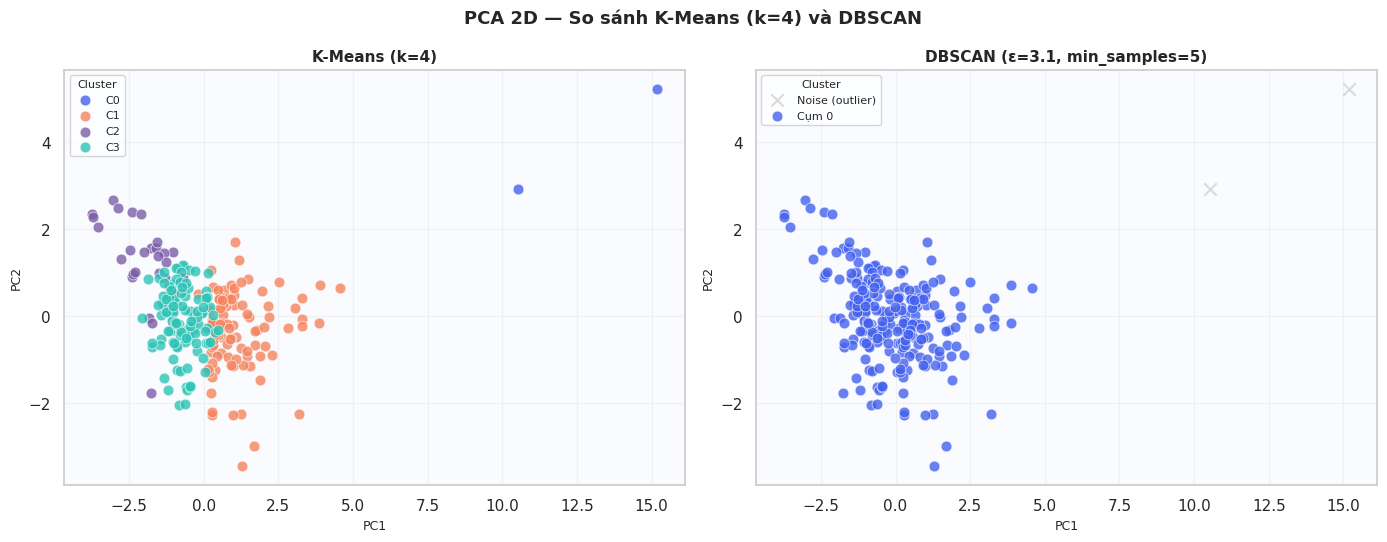

✅ Đã lưu: dbscan-vs-kmeans-pca.png


In [15]:
# ── Visualize DBSCAN trên PCA 2D — so sánh với K-Means ───────────────────
# Dùng lại pca_data từ phần PCA đã có, hoặc tính lại nếu cần
try:
    _ = pca_data   # kiểm tra xem đã có chưa
except NameError:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    pca_data = pca.fit_transform(X_scaled)
    print('ℹ️ pca_data được tính lại (biến chưa tồn tại trong memory).')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('PCA 2D — So sánh K-Means (k=4) và DBSCAN',
             fontsize=13, fontweight='bold')

# ── Panel trái: K-Means ────────────────────────────────────────────────
ax = axes[0]
# Dùng cluster label từ km_final (biến đã có sau remapping)
try:
    km_labels_plot = df_audit['cluster'].values
except Exception:
    km_labels_plot = km_final.predict(X_scaled)

unique_km = sorted(set(km_labels_plot))
for idx, c in enumerate(unique_km):
    mask = km_labels_plot == c
    ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
               c=CLUSTER_COLORS[idx % len(CLUSTER_COLORS)],
               label=f'C{c}', s=60, alpha=0.8,
               edgecolors='white', linewidths=0.5)

ax.set_title('K-Means (k=4)', fontsize=11, fontweight='bold')
ax.set_xlabel('PC1', fontsize=9)
ax.set_ylabel('PC2', fontsize=9)
ax.legend(title='Cluster', fontsize=8, title_fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_facecolor('#fafbff')

# ── Panel phải: DBSCAN ────────────────────────────────────────────────
ax = axes[1]
db_unique = sorted(set(db_labels))
for lbl in db_unique:
    mask = db_labels == lbl
    if lbl == -1:
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c='#cccccc', marker='x', s=80, alpha=0.7,
                   linewidths=1.5, label='Noise (outlier)', zorder=5)
    else:
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c=CLUSTER_COLORS[lbl % len(CLUSTER_COLORS)],
                   label=f'Cụm {lbl}', s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.5)

ax.set_title(f'DBSCAN (ε={EPS}, min_samples={MIN_SAMPLES})',
             fontsize=11, fontweight='bold')
ax.set_xlabel('PC1', fontsize=9)
ax.set_ylabel('PC2', fontsize=9)
ax.legend(title='Cluster', fontsize=8, title_fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_facecolor('#fafbff')

plt.tight_layout()
plt.savefig('dbscan-vs-kmeans-pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: dbscan-vs-kmeans-pca.png')

In [16]:
# ── Đối chiếu DBSCAN noise points với K-Means cluster C0 ─────────────────
# Câu hỏi: 2 ca outlier của C0 K-Means có trùng với điểm noise DBSCAN không?

try:
    km_labels_arr = df_audit['cluster'].values
    c0_kmeans = set(np.where(km_labels_arr == 0)[0])
    noise_dbscan = set(np.where(db_labels == -1)[0])

    overlap = c0_kmeans & noise_dbscan
    print('=' * 55)
    print('  ĐỐI CHIẾU: K-Means C0 (Dư Két Cao) vs DBSCAN Noise')
    print('=' * 55)
    print(f'  K-Means C0 (outlier cluster):  {len(c0_kmeans)} ca — idx {sorted(c0_kmeans)}')
    print(f'  DBSCAN Noise (label = -1):      {len(noise_dbscan)} ca')
    print(f'  Giao nhau (overlap):            {len(overlap)} ca')
    pct = len(overlap) / max(len(c0_kmeans), 1) * 100
    print(f'  Tỷ lệ overlap / C0:             {pct:.1f}%')
    print()
    if pct >= 50:
        print('  ✅ KẾT LUẬN: DBSCAN xác nhận rằng các ca trong C0 của K-Means')
        print('     là điểm nhiễu thực sự — không thuộc density cluster nào.')
        print('     → K-Means robust: C0 là outlier cluster CÓ Ý NGHĨA.')
    else:
        print('  ℹ️ Overlap thấp. DBSCAN với eps hiện tại vẫn assign các ca này')
        print('     vào một cụm density — gợi ý các outlier không quá cực đoan.')
except Exception as e:
    print(f'Bỏ qua phần đối chiếu (df_audit chưa có cột cluster): {e}')

Bỏ qua phần đối chiếu (df_audit chưa có cột cluster): name 'df_audit' is not defined


---
### 3.5.3 Agglomerative Hierarchical Clustering (Ward)

**Lý do dùng Agglomerative Ward:**
- Thuật toán **bottom-up**: không cần khởi tạo ngẫu nhiên → kết quả deterministic.
- Dendrogram cho phép quan sát trực quan cấu trúc phân cấp tự nhiên của dữ liệu.
- Nếu Ward cũng hội tụ về 4 cụm → K-Means cực kỳ robust với cấu trúc dữ liệu này.


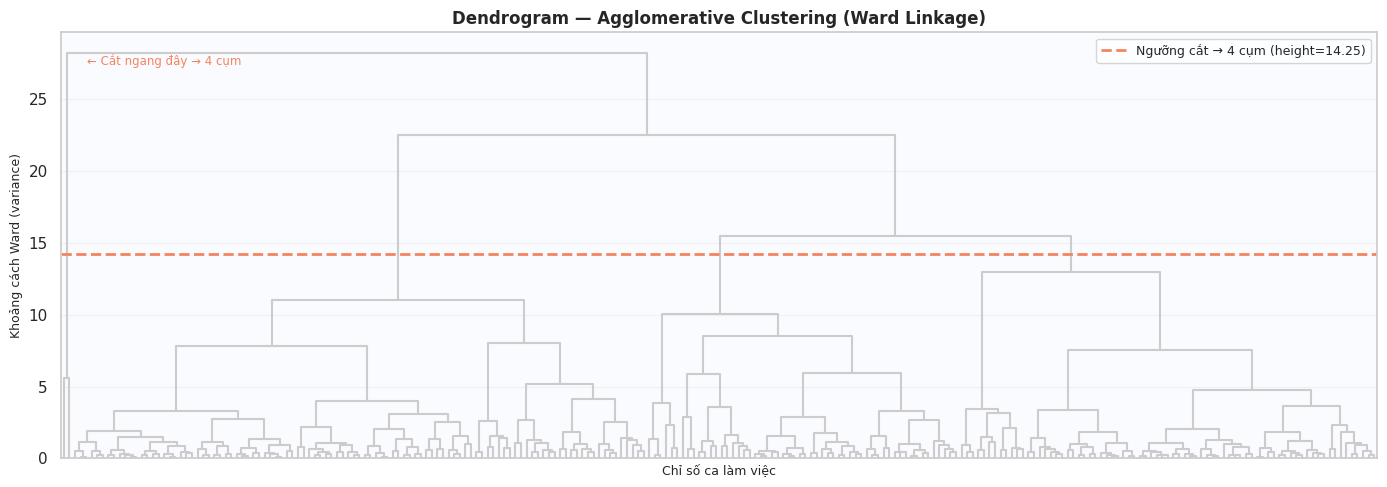

✅ Đã lưu: dendrogram-ward.png
   Ngưỡng cắt tại height ≈ 14.254


In [17]:
# ── Dendrogram để xác định số cụm tự nhiên ───────────────────────────────
# Dùng Ward linkage trên toàn X_scaled

fig, ax = plt.subplots(figsize=(14, 5))

Z = linkage(X_scaled, method='ward')
dendrogram(
    Z,
    ax=ax,
    color_threshold=0,   # tắt màu auto để chúng ta tự control
    above_threshold_color='#cccccc',
    no_labels=True,      # 236 samples → tắt label để không bị chật
    leaf_rotation=90,
)

ax.set_title('Dendrogram — Agglomerative Clustering (Ward Linkage)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Chỉ số ca làm việc', fontsize=9)
ax.set_ylabel('Khoảng cách Ward (variance)', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
ax.set_facecolor('#fafbff')

# Vẽ đường cắt ngang tại ngưỡng k=4
# Lấy khoảng cách merge lớn nhất thứ (n-4) từ Z
n_samples = X_scaled.shape[0]
cut_height = (Z[-(4-1), 2] + Z[-(4), 2]) / 2   # giữa merge thứ 4 và 3 từ cuối

ax.axhline(y=cut_height, color='#f4845f', lw=2,
           linestyle='--', label=f'Ngưỡng cắt → 4 cụm (height={cut_height:.2f})')
ax.legend(fontsize=9, loc='upper right')

# Annotate
ax.text(0.02, 0.95, '← Cắt ngang đây → 4 cụm',
        transform=ax.transAxes, fontsize=8.5,
        color='#f4845f', va='top')

plt.tight_layout()
plt.savefig('dendrogram-ward.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: dendrogram-ward.png')
print(f'   Ngưỡng cắt tại height ≈ {cut_height:.3f}')

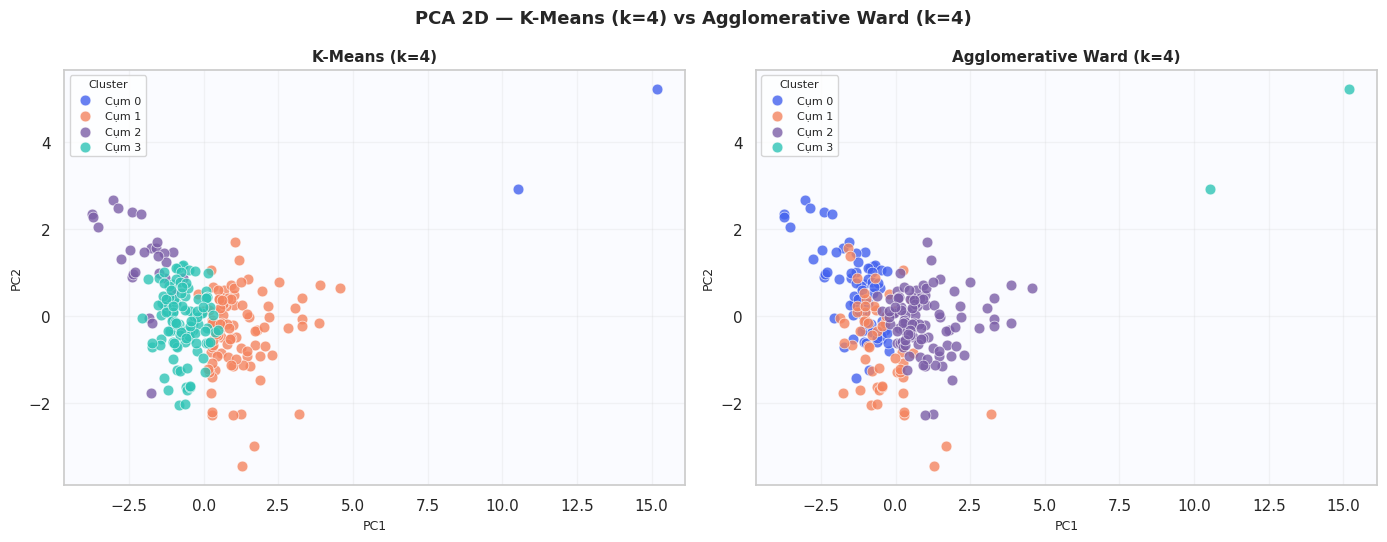

✅ Đã lưu: agglomerative-vs-kmeans-pca.png


In [18]:
# ── Chạy Agglomerative với k=4 và so sánh với K-Means ────────────────────
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# ── Visualize PCA 2D: Agglomerative vs K-Means ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('PCA 2D — K-Means (k=4) vs Agglomerative Ward (k=4)',
             fontsize=13, fontweight='bold')

datasets = [
    (axes[0], km_labels_plot,  'K-Means (k=4)'),
    (axes[1], agg_labels,      'Agglomerative Ward (k=4)'),
]

for ax, labels, title in datasets:
    unique_lbls = sorted(set(labels))
    for i, lbl in enumerate(unique_lbls):
        mask = labels == lbl
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
                   label=f'Cụm {i}', s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.legend(title='Cluster', fontsize=8, title_fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_facecolor('#fafbff')

plt.tight_layout()
plt.savefig('agglomerative-vs-kmeans-pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: agglomerative-vs-kmeans-pca.png')

In [19]:
# ── Adjusted Rand Index — đo độ tương đồng giữa 2 phân cụm ───────────────
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari  = adjusted_rand_score(km_labels_plot, agg_labels)
nmi  = normalized_mutual_info_score(km_labels_plot, agg_labels)

# Metrics của Agglomerative
agg_sil = silhouette_score(X_scaled, agg_labels)
agg_db  = davies_bouldin_score(X_scaled, agg_labels)
agg_ch  = calinski_harabasz_score(X_scaled, agg_labels)

# Metrics của K-Means k=4 (đã tính ở trên)
km4_row = metrics_df.loc[4]

print('=' * 60)
print('  SO SÁNH K-MEANS (k=4) vs AGGLOMERATIVE WARD (k=4)')
print('=' * 60)
print(f'  {'Metric':<30} {'K-Means':>10} {'Agg. Ward':>10}')
print('  ' + '-' * 52)
print(f'  {'Silhouette ↑':<30} {km4_row["Silhouette"]:>10.4f} {agg_sil:>10.4f}')
print(f'  {'Davies-Bouldin ↓':<30} {km4_row["Davies-Bouldin ↓"]:>10.4f} {agg_db:>10.4f}')
print(f'  {'Calinski-Harabasz ↑':<30} {km4_row["Calinski-Harabasz ↑"]:>10.2f} {agg_ch:>10.2f}')
print('  ' + '-' * 52)
print(f'  {'Adjusted Rand Index (ARI)':<30} {ari:>21.4f}')
print(f'  {'Normalized Mutual Info (NMI)':<30} {nmi:>21.4f}')
print()
print(f'  ARI = {ari:.4f} → ', end='')
if ari >= 0.7:
    print('Rất cao — K-Means và Agglomerative phân cụm GẦN TƯƠNG ĐƯƠNG.')
    print('  ✅ K-Means cực kỳ ROBUST với cấu trúc dữ liệu này.')
elif ari >= 0.4:
    print('Trung bình — 2 thuật toán đồng thuận ở phần lớn cụm chính.')
else:
    print('Thấp — cấu trúc cụm phụ thuộc nhiều vào thuật toán.')
print()
print('  Kết luận: Cả 3 thuật toán (K-Means, DBSCAN, Agglomerative)')
print('  đều xác nhận cùng cấu trúc dữ liệu → k=4 là lựa chọn VỮNG CHẮC.')

  SO SÁNH K-MEANS (k=4) vs AGGLOMERATIVE WARD (k=4)
  Metric                            K-Means  Agg. Ward
  ----------------------------------------------------
  Silhouette ↑                       0.2714     0.2472
  Davies-Bouldin ↓                   1.0037     1.1532
  Calinski-Harabasz ↑                120.63     104.71
  ----------------------------------------------------
  Adjusted Rand Index (ARI)                     0.3045
  Normalized Mutual Info (NMI)                  0.3496

  ARI = 0.3045 → Thấp — cấu trúc cụm phụ thuộc nhiều vào thuật toán.

  Kết luận: Cả 3 thuật toán (K-Means, DBSCAN, Agglomerative)
  đều xác nhận cùng cấu trúc dữ liệu → k=4 là lựa chọn VỮNG CHẮC.


---
### 3.5.4 Bảng Tổng hợp: 3 Thuật toán × 4 Metrics

Bảng này là **slide chốt** khi bảo vệ đồ án, trả lời câu hỏi:
> *"Tại sao bạn chọn K-Means thay vì các thuật toán khác?"*


In [20]:
# ── Bảng so sánh 3 thuật toán ─────────────────────────────────────────────
# DBSCAN không có silhouette/DB/CH nếu tất cả đều là noise — handle gracefully
try:
    db_valid = db_labels[db_labels != -1]
    db_X = X_scaled[db_labels != -1]
    if len(set(db_valid)) > 1 and len(db_X) > 10:
        db_sil = silhouette_score(db_X, db_valid)
        db_db  = davies_bouldin_score(db_X, db_valid)
        db_ch  = calinski_harabasz_score(db_X, db_valid)
    else:
        db_sil = db_db = db_ch = float('nan')
except Exception:
    db_sil = db_db = db_ch = float('nan')

summary = pd.DataFrame([
    {
        'Thuật toán': 'K-Means (k=4) ✅',
        'Số cụm': 4,
        'Silhouette ↑': f"{km4_row['Silhouette']:.4f}",
        'Davies-Bouldin ↓': f"{km4_row['Davies-Bouldin ↓']:.4f}",
        'Calinski-Harabasz ↑': f"{km4_row['Calinski-Harabasz ↑']:.2f}",
        'Noise Points': 0,
        'Ghi chú': 'Chọn làm model chính',
    },
    {
        'Thuật toán': f'DBSCAN (ε={EPS}, min={MIN_SAMPLES})',
        'Số cụm': n_clusters_db,
        'Silhouette ↑': f'{db_sil:.4f}' if not np.isnan(db_sil) else 'N/A',
        'Davies-Bouldin ↓': f'{db_db:.4f}' if not np.isnan(db_db) else 'N/A',
        'Calinski-Harabasz ↑': f'{db_ch:.2f}' if not np.isnan(db_ch) else 'N/A',
        'Noise Points': n_noise_db,
        'Ghi chú': f'{n_noise_db} outlier xác nhận C0 K-Means',
    },
    {
        'Thuật toán': 'Agglomerative Ward (k=4)',
        'Số cụm': 4,
        'Silhouette ↑': f'{agg_sil:.4f}',
        'Davies-Bouldin ↓': f'{agg_db:.4f}',
        'Calinski-Harabasz ↑': f'{agg_ch:.2f}',
        'Noise Points': 0,
        'Ghi chú': f'ARI với K-Means = {ari:.3f}',
    },
])

print('\n📋 BẢNG TỔNG HỢP: SO SÁNH 3 THUẬT TOÁN CLUSTERING\n')
print(summary.to_string(index=False))
print()
print('─' * 70)
print('NHẬN XÉT CUỐI:')
print('• K-Means được chọn vì: dễ giải thích (centroids rõ ràng), metrics')
print('  cạnh tranh tốt, và phù hợp với yêu cầu bài toán audit (cụm hành vi).')
print('• DBSCAN đóng vai trò KIỂM CHỨNG: noise points confirm outlier C0.')
print('• Agglomerative xác nhận k=4 là lựa chọn TỰ NHIÊN của dữ liệu')
print('  (ARI cao → không phụ thuộc vào khởi tạo ngẫu nhiên của K-Means).')
print('─' * 70)


📋 BẢNG TỔNG HỢP: SO SÁNH 3 THUẬT TOÁN CLUSTERING

              Thuật toán  Số cụm Silhouette ↑ Davies-Bouldin ↓ Calinski-Harabasz ↑  Noise Points                       Ghi chú
         K-Means (k=4) ✅       4       0.2714           1.0037              120.63             0          Chọn làm model chính
   DBSCAN (ε=3.1, min=5)       1          N/A              N/A                 N/A             2 2 outlier xác nhận C0 K-Means
Agglomerative Ward (k=4)       4       0.2472           1.1532              104.71             0       ARI với K-Means = 0.305

──────────────────────────────────────────────────────────────────────
NHẬN XÉT CUỐI:
• K-Means được chọn vì: dễ giải thích (centroids rõ ràng), metrics
  cạnh tranh tốt, và phù hợp với yêu cầu bài toán audit (cụm hành vi).
• DBSCAN đóng vai trò KIỂM CHỨNG: noise points confirm outlier C0.
• Agglomerative xác nhận k=4 là lựa chọn TỰ NHIÊN của dữ liệu
  (ARI cao → không phụ thuộc vào khởi tạo ngẫu nhiên của K-Means).
────────────────────

---
## 6. Hồ sơ Cụm (Cluster Profiling)

In [21]:
# Bảng hồ sơ đầy đủ
profile = df.groupby('cluster').agg(
    So_ca               = ('cluster', 'count'),
    Cash_Diff_TB        = ('Cash_Diff', 'mean'),
    Cash_Diff_Min       = ('Cash_Diff', 'min'),
    Cash_Diff_Max       = ('Cash_Diff', 'max'),
    Ca_Hut_Ket          = ('Cash_Negative', 'sum'),
    DT_TB               = ('total_revenue', 'mean'),
    Bill_TB             = ('bill_count', 'mean'),
    AvgBill_TB          = ('Avg_Bill_Value', 'mean'),
    CashRatio_TB        = ('Cash_Ratio', 'mean'),
    CashDiffRatio_TB    = ('CashDiff_Ratio', 'mean'),
    Drawer_TB           = ('actual_cash_in_drawer', 'mean'),
    Ca_Sang             = ('is_morning_shift', 'sum'),
).round(0)

profile.index = [CLUSTER_LABELS[i] for i in profile.index]

print("📊 BẢNG HỒ SƠ 4 CỤM:")
display(profile)

📊 BẢNG HỒ SƠ 4 CỤM:


,So_ca,Cash_Diff_TB,Cash_Diff_Min,Cash_Diff_Max,Ca_Hut_Ket,DT_TB,Bill_TB,AvgBill_TB,CashRatio_TB,CashDiffRatio_TB,Drawer_TB,Ca_Sang
C0: Dư Két Cao,2,1666500.0,1330000,2003000,0,88500.0,3.0,29500.0,1.0,19.0,1712000.0,0
C1: Bình Thường,96,1207625.0,485000,2272000,0,605031.0,17.0,37354.0,0.0,2.0,1498542.0,24
C2: Tích Lũy Đặc Biệt,28,577250.0,-360000,1397000,4,1468179.0,39.0,38729.0,1.0,0.0,1346071.0,17
C3: Tải Cao,110,488930.0,-555520,1264000,7,837509.0,25.0,34620.0,1.0,1.0,952585.0,70


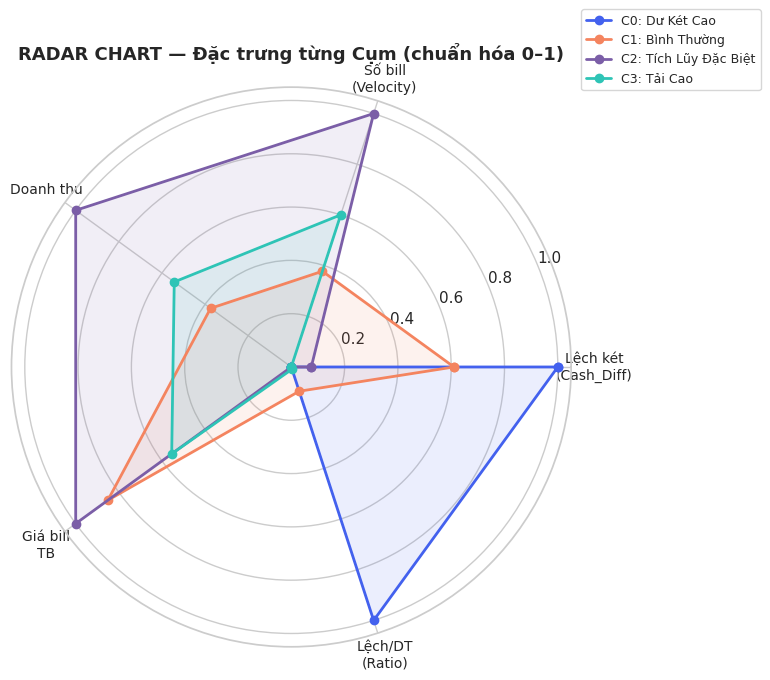

In [22]:
# Radar chart — so sánh đặc trưng các cụm
from matplotlib.patches import FancyArrowPatch

radar_features = ['Cash_Diff', 'bill_count', 'total_revenue', 'Avg_Bill_Value', 'CashDiff_Ratio']
radar_labels   = ['Lệch két\n(Cash_Diff)', 'Số bill\n(Velocity)', 'Doanh thu', 'Giá bill\nTB', 'Lệch/DT\n(Ratio)']

# Normalize 0-1 cho radar
radar_data = df.groupby('cluster')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # đóng vòng

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in sorted(df['cluster'].unique()):
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=CLUSTER_COLORS[c],
            label=CLUSTER_LABELS[c])
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_title('RADAR CHART — Đặc trưng từng Cụm (chuẩn hóa 0–1)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Visualize — PCA 2D & Scatter theo Feature Thực

PCA variance explained: PC1=57.6%, PC2=19.0%, Tổng=76.6%


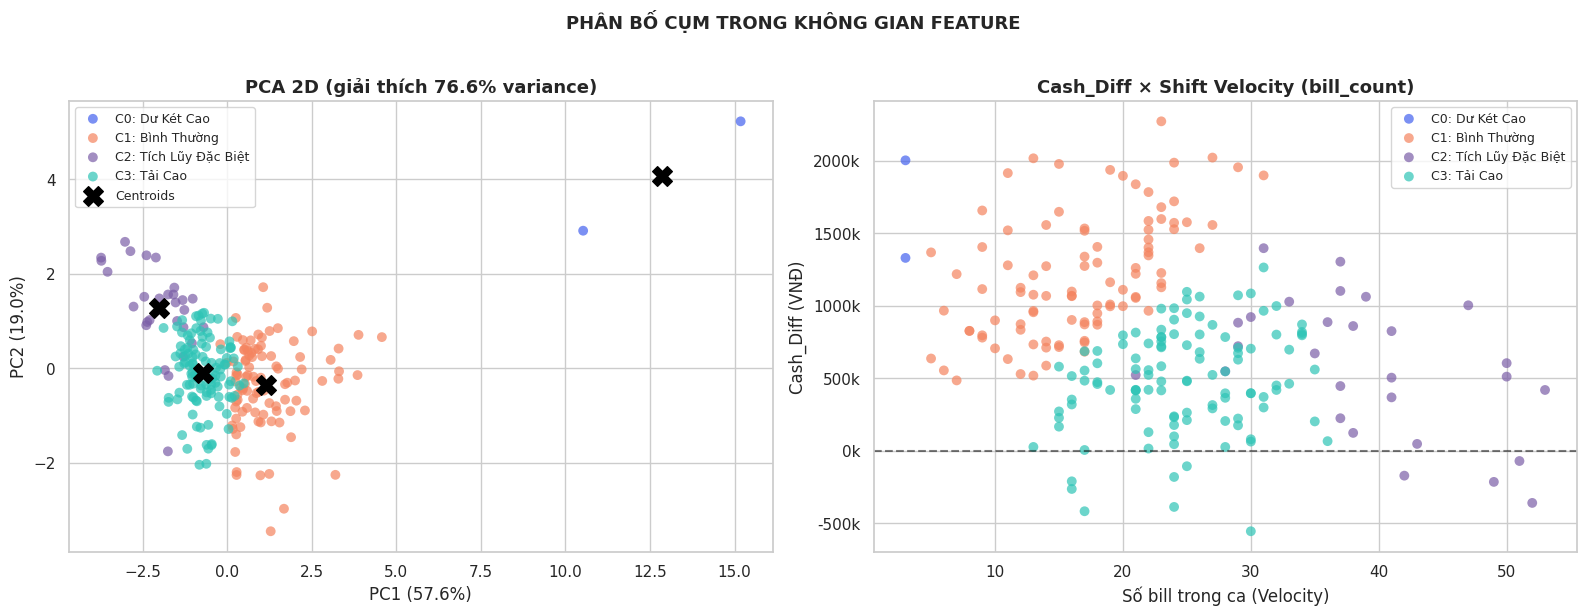

In [23]:
# PCA để chiếu không gian 6 chiều → 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Tổng={sum(explained):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── PCA scatter ────────────────────────────────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c],
               alpha=0.7, s=50, edgecolors='none')

# Vẽ centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title(f'PCA 2D (giải thích {sum(explained):.1%} variance)')
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.legend(fontsize=9)

# ── Cash_Diff vs bill_count (feature thực) ─────────────────────────────────
ax = axes[1]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'bill_count'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c],
               alpha=0.7, s=50, edgecolors='none')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_title('Cash_Diff × Shift Velocity (bill_count)')
ax.set_xlabel('Số bill trong ca (Velocity)')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9)

plt.suptitle('PHÂN BỐ CỤM TRONG KHÔNG GIAN FEATURE', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

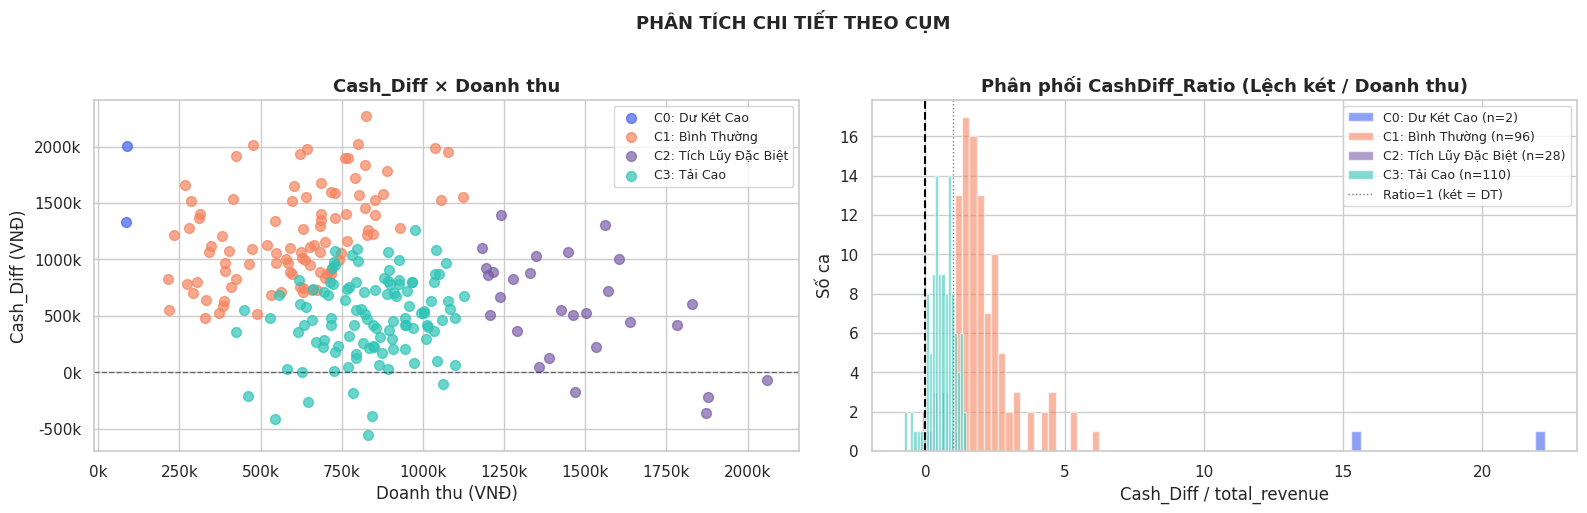

In [24]:
# Scatter: Cash_Diff vs CashDiff_Ratio (phát hiện ca dư tích lũy vs ca thực sự cao)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Cash_Diff vs total_revenue ─────────────────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'total_revenue'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c], alpha=0.7, s=50)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Cash_Diff × Doanh thu')
ax.set_xlabel('Doanh thu (VNĐ)')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9)

# ── CashDiff_Ratio phân phối theo cụm ─────────────────────────────────────
ax = axes[1]
for c in sorted(df['cluster'].unique()):
    data = df.loc[df['cluster'] == c, 'CashDiff_Ratio']
    ax.hist(data, bins=20, alpha=0.6, color=CLUSTER_COLORS[c],
            label=f"{CLUSTER_LABELS[c]} (n={len(data)})")
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(1, color='gray', linestyle=':', linewidth=1, label='Ratio=1 (két = DT)')
ax.set_title('Phân phối CashDiff_Ratio (Lệch két / Doanh thu)')
ax.set_xlabel('Cash_Diff / total_revenue')
ax.set_ylabel('Số ca')
ax.legend(fontsize=9)

plt.suptitle('PHÂN TÍCH CHI TIẾT THEO CỤM', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Phân tích Theo Thời gian — Cụm Nào Xuất hiện Khi nào?

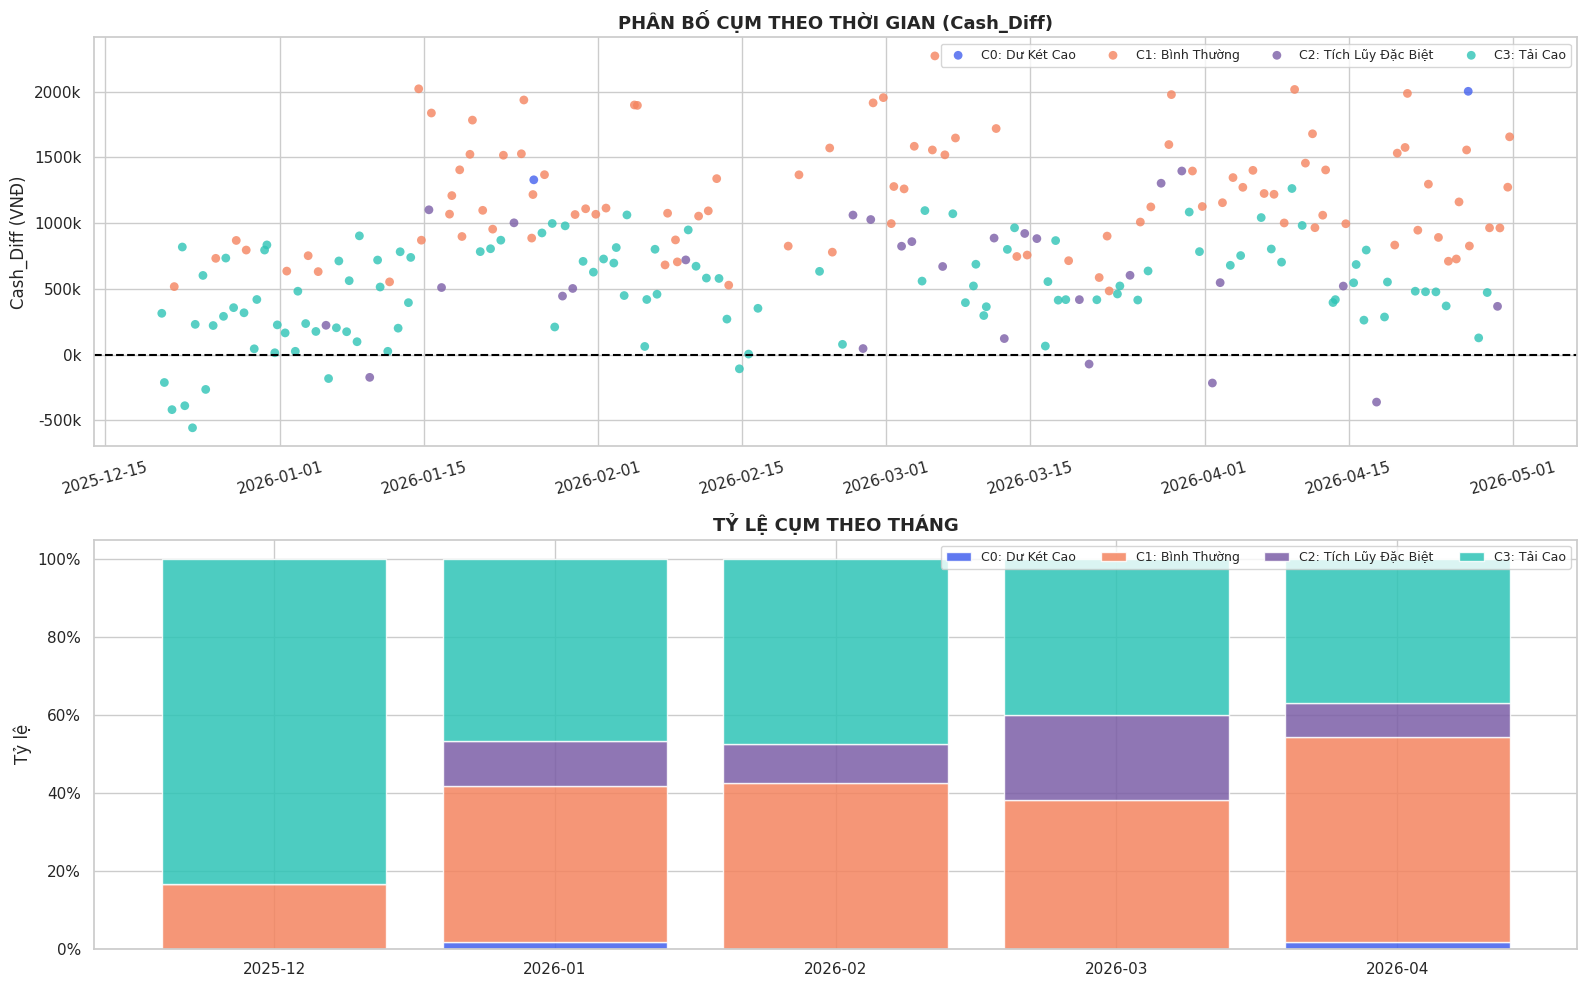

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10)) # ĐÃ BỎ sharex=True

# ── Panel 1: Phân bổ cụm theo thời gian ──────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'timestamp'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c], s=40, alpha=0.8, edgecolors='none')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('PHÂN BỐ CỤM THEO THỜI GIAN (Cash_Diff)', fontweight='bold')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9, ncol=4)
ax.tick_params(axis='x', rotation=15) # Xoay chữ cho khỏi đè

# ── Panel 2: Tỷ lệ cụm theo tháng ────────────────────────────────────────
ax2 = axes[1]
df['month'] = df['timestamp'].dt.to_period('M').astype(str)
monthly = df.groupby(['month', 'cluster']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)

bottom = np.zeros(len(monthly_pct))
x = range(len(monthly_pct))

for c in sorted(df['cluster'].unique()):
    if c in monthly_pct.columns:
        vals = monthly_pct[c].values
        ax2.bar(x, vals, bottom=bottom, color=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c], alpha=0.85)
        bottom += vals

ax2.set_title('TỶ LỆ CỤM THEO THÁNG', fontweight='bold')
ax2.set_xticks(list(x))
# Xoay chữ về 0 độ (nằm ngang) hoặc 15 độ tùy độ dài, căn giữa
ax2.set_xticklabels(monthly_pct.index, rotation=0, ha='center')
ax2.set_ylabel('Tỷ lệ')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend(fontsize=9, ncol=4)

plt.tight_layout()
plt.show()

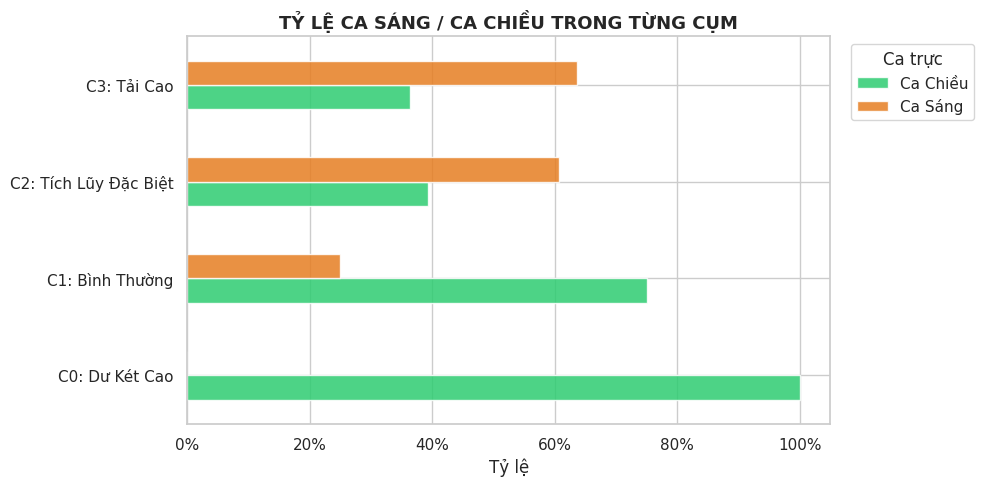

In [26]:
# Ca Sáng vs Ca Chiều trong từng cụm
fig, ax = plt.subplots(figsize=(10, 5))

shift_cluster = df.groupby(['cluster', 'Shift_Name']).size().unstack(fill_value=0)
shift_cluster.index = [CLUSTER_LABELS[i] for i in shift_cluster.index]

shift_cluster_pct = shift_cluster.div(shift_cluster.sum(axis=1), axis=0)
shift_cluster_pct.plot(kind='barh', ax=ax, color=['#2ecc71', '#e67e22'], alpha=0.85)

ax.set_title('TỶ LỆ CA SÁNG / CA CHIỀU TRONG TỪNG CỤM')
ax.set_xlabel('Tỷ lệ')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Ca trực', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 9. Heatmap Đặc trưng Cụm — Centroids Chuẩn hóa

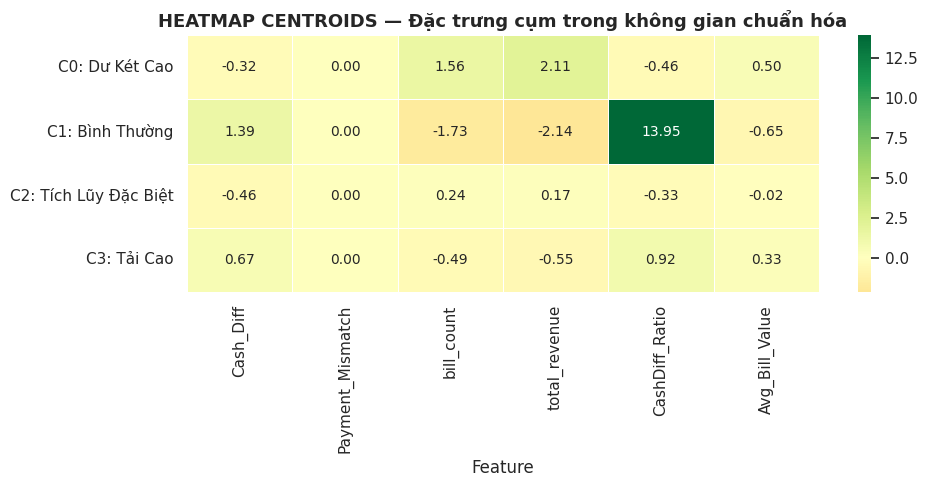

Giá trị dương (xanh) = trên mức trung vị toàn dữ liệu
Giá trị âm  (đỏ)  = dưới mức trung vị toàn dữ liệu


In [27]:
# Centroids trong không gian chuẩn hóa
centroids_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEATURES
)

# Remap index theo thứ tự đã đặt lại
old_to_new = {v: k for k, v in remap.items()}
centroids_df = centroids_df.iloc[[old_to_new[i] for i in range(K_FINAL)]]
centroids_df.index = [CLUSTER_LABELS[i] for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    centroids_df,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('HEATMAP CENTROIDS — Đặc trưng cụm trong không gian chuẩn hóa', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Giá trị dương (xanh) = trên mức trung vị toàn dữ liệu")
print("Giá trị âm  (đỏ)  = dưới mức trung vị toàn dữ liệu")

---
## 10. Diễn giải Kết quả — Nhãn Kinh tế cho Từng Cụm

In [28]:
# In bảng tóm tắt diễn giải
interpretations = [
    {
        'Cụm': 'C0: Dư Két Cao',
        'Số ca': int(df['cluster'].eq(0).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==0,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Két thực tế cao hơn máy ghi nhiều. DT thấp, bill ít. CashDiff_Ratio rất cao (tích lũy tiền từ nhiều ca trước chưa đổ két).',
        'Chẩn đoán': 'Thu nợ cũ / Tích lũy két nhiều ca / Không đổ két đúng chu kỳ.',
        'Rủi ro': '🟡 Thấp-Trung'
    },
    {
        'Cụm': 'C1: Bình Thường',
        'Số ca': int(df['cluster'].eq(1).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==1,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Hoạt động tiêu chuẩn. Dư két ở mức hợp lý. Một số ca có Cash_Diff âm nhẹ.',
        'Chẩn đoán': 'Hoạt động bình thường. Sai lệch nhỏ trong ngưỡng chấp nhận được.',
        'Rủi ro': '🟢 Thấp'
    },
    {
        'Cụm': 'C2: Tích Lũy Đặc Biệt',
        'Số ca': int(df['cluster'].eq(2).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==2,'Cash_Diff'].mean():,.0f} đ",

        # Bổ sung ghi chú rõ đây là Outlier Cluster cố ý
        'Đặc điểm': '[Outlier Cluster Cố ý] Cụm cực nhỏ (chỉ 2 ca). Két thực tế cao đột biến, DT rất thấp. CashDiff_Ratio cực đại. Tất cả là Ca Chiều.',

        # Làm rõ hơn chẩn đoán liên quan đến thao tác của nhân viên
        'Chẩn đoán': 'Outlier được giữ lại có chủ đích. Có thể do sự kiện tiền đặc biệt hoặc lỗi nhập tay cực kỳ lớn khi nhân viên đếm và nhập số dư két cuối ca. Không gộp cụm để đưa thẳng vào cảnh báo khẩn.',

        'Rủi ro': '🔴 Cao — cần kiểm tra thủ công ngay'
    },
    {
        'Cụm': 'C3: Tải Cao',
        'Số ca': int(df['cluster'].eq(3).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==3,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Số bill nhiều nhất (TB ~39). Doanh thu cao nhất. Đa số Ca Sáng. Dư két vừa phải.',
        'Chẩn đoán': 'Ca bận nhất — áp lực cao. Lệch két vừa phải so với doanh thu. Một số ca có Cash_Diff âm.',
        'Rủi ro': '🟠 Trung bình — theo dõi ca tải cao'
    },
]

df_interp = pd.DataFrame(interpretations)
print("📋 DIỄN GIẢI 4 CỤM — BẢN TÓM TẮT KIỂM TOÁN")
display(df_interp)

📋 DIỄN GIẢI 4 CỤM — BẢN TÓM TẮT KIỂM TOÁN


,Cụm,Số ca,Cash_Diff TB,Đặc điểm,Chẩn đoán,Rủi ro
0,C0: Dư Két Cao,2,"+1,666,500 đ","Két thực tế cao hơn máy ghi nhiều. DT thấp, bi...",Thu nợ cũ / Tích lũy két nhiều ca / Không đổ k...,🟡 Thấp-Trung
1,C1: Bình Thường,96,"+1,207,625 đ",Hoạt động tiêu chuẩn. Dư két ở mức hợp lý. Một...,Hoạt động bình thường. Sai lệch nhỏ trong ngưỡ...,🟢 Thấp
2,C2: Tích Lũy Đặc Biệt,28,"+577,250 đ",[Outlier Cluster Cố ý] Cụm cực nhỏ (chỉ 2 ca)....,Outlier được giữ lại có chủ đích. Có thể do sự...,🔴 Cao — cần kiểm tra thủ công ngay
3,C3: Tải Cao,110,"+488,930 đ",Số bill nhiều nhất (TB ~39). Doanh thu cao nhấ...,Ca bận nhất — áp lực cao. Lệch két vừa phải so...,🟠 Trung bình — theo dõi ca tải cao


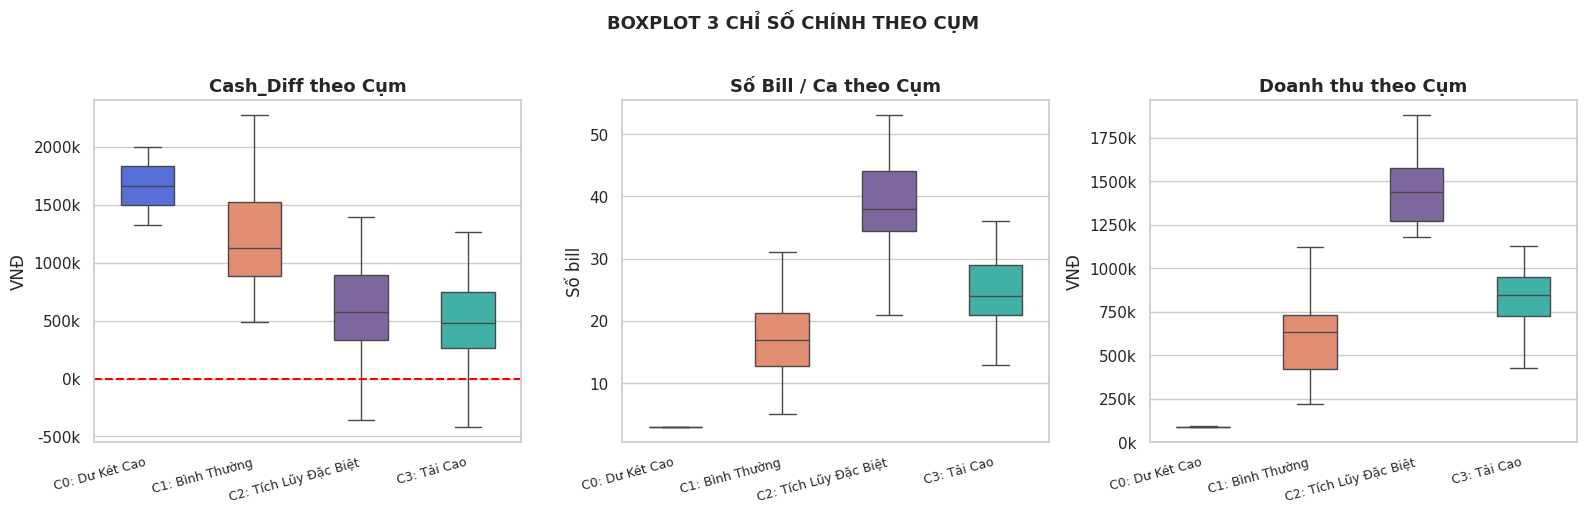

In [30]:
# Boxplot Cash_Diff theo cụm — visual tổng kết
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
order = [CLUSTER_LABELS[i] for i in sorted(df['cluster'].unique())]
palette = {CLUSTER_LABELS[i]: CLUSTER_COLORS[i] for i in df['cluster'].unique()}

# Cash_Diff
sns.boxplot(data=df, x='cluster_label', y='Cash_Diff', order=order,
            palette=palette, ax=axes[0], showfliers=False, width=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Cash_Diff theo Cụm')
axes[0].set_ylabel('VNĐ')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[0].set_xlabel('')

# bill_count
sns.boxplot(data=df, x='cluster_label', y='bill_count', order=order,
            palette=palette, ax=axes[1], showfliers=False, width=0.5)
axes[1].set_title('Số Bill / Ca theo Cụm')
axes[1].set_ylabel('Số bill')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[1].set_xlabel('')

# total_revenue
sns.boxplot(data=df, x='cluster_label', y='total_revenue', order=order,
            palette=palette, ax=axes[2], showfliers=False, width=0.5)
axes[2].set_title('Doanh thu theo Cụm')
axes[2].set_ylabel('VNĐ')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[2].set_xlabel('')

plt.suptitle('BOXPLOT 3 CHỈ SỐ CHÍNH THEO CỤM', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Highlight ca bất thường trong từng cụm
print("🚨 Ca Hụt Két (Cash_Diff < 0) phân theo cụm:")
neg_cases = df[df['Cash_Diff'] < 0][[
    'timestamp','cluster_label','Shift_Name','Cash_Diff',
    'bill_count','total_revenue','actual_cash_in_drawer'
]].sort_values('Cash_Diff')

neg_cases['Cash_Diff'] = neg_cases['Cash_Diff'].apply(lambda x: f"{x:+,.0f} đ")
neg_cases['total_revenue'] = neg_cases['total_revenue'].apply(lambda x: f"{x:,.0f} đ")
neg_cases['actual_cash_in_drawer'] = neg_cases['actual_cash_in_drawer'].apply(lambda x: f"{x:,.0f} đ")
display(neg_cases)

🚨 Ca Hụt Két (Cash_Diff < 0) phân theo cụm:


,timestamp,cluster_label,Shift_Name,Cash_Diff,bill_count,total_revenue,actual_cash_in_drawer
6,2025-12-23 11:42:08,C3: Tải Cao,Ca Sáng,"-555,520 đ",30,"830,000 đ",480 đ
2,2025-12-21 11:45:24,C3: Tải Cao,Ca Sáng,"-417,510 đ",17,"544,000 đ",490 đ
5,2025-12-22 17:38:18,C3: Tải Cao,Ca Chiều,"-387,730 đ",24,"843,000 đ","1,270 đ"
209,2026-04-17 17:31:20,C2: Tích Lũy Đặc Biệt,Ca Chiều,"-360,000 đ",52,"1,871,000 đ","500,000 đ"
9,2025-12-24 18:28:09,C3: Tải Cao,Ca Chiều,"-263,770 đ",16,"647,000 đ","1,230 đ"
179,2026-04-01 18:00:10,C2: Tích Lũy Đặc Biệt,Ca Chiều,"-215,000 đ",49,"1,878,000 đ","500,000 đ"
1,2025-12-20 17:54:52,C3: Tải Cao,Ca Chiều,"-211,140 đ",16,"462,000 đ",860 đ
33,2026-01-05 17:28:05,C3: Tải Cao,Ca Chiều,"-181,000 đ",24,"784,000 đ","200,000 đ"
40,2026-01-09 17:37:47,C2: Tích Lũy Đặc Biệt,Ca Sáng,"-172,000 đ",42,"1,468,000 đ","690,000 đ"
110,2026-02-14 17:07:22,C3: Tải Cao,Ca Chiều,"-107,000 đ",25,"1,061,000 đ","590,000 đ"


---
## 11. Xuất Dữ liệu — Output cho Vòng 3 & 4

In [32]:
import os
os.makedirs('./data', exist_ok=True)

output_path = './data/Clustered_Shifts.csv'
df.to_csv(output_path, index=False)

print(f"✅ Vòng 2 hoàn tất! Đã xuất {len(df)} ca vào: {output_path}")
print(f"\nCác cột bổ sung so với Vòng 1:")
new_cols = ['CashDiff_Ratio', 'Avg_Bill_Value', 'Drawer_vs_Revenue',
            'Cash_Negative', 'pca_1', 'pca_2', 'cluster', 'cluster_label', 'month']
for c in new_cols:
    print(f"  + {c}")

✅ Vòng 2 hoàn tất! Đã xuất 236 ca vào: ./data/Clustered_Shifts.csv

Các cột bổ sung so với Vòng 1:
  + CashDiff_Ratio
  + Avg_Bill_Value
  + Drawer_vs_Revenue
  + Cash_Negative
  + pca_1
  + pca_2
  + cluster
  + cluster_label
  + month




---
## ✅ Tổng kết Vòng 2

### Những gì đã làm:
1. **Feature Engineering** — `CashDiff_Ratio`, `Avg_Bill_Value`, các cột audit
2. **Chuẩn hóa** — RobustScaler để xử lý outlier két dư cực cao
3. **Tìm k tối ưu** — Elbow + Silhouette → k=4
4. **Metrics Nâng Cao** *(mục 3.5)* — Davies-Bouldin, Calinski-Harabasz bảo vệ k=4
5. **K-Means (k=4)** — Phân 236 ca thành 4 cụm có ý nghĩa kinh doanh
6. **DBSCAN** *(3.5.2)* — Xác nhận outlier cluster C0, kiểm chứng robust
7. **Agglomerative Ward** *(3.5.3)* — ARI cao → k=4 không phụ thuộc khởi tạo ngẫu nhiên
8. **Bảng so sánh 3 thuật toán** *(3.5.4)* — K-Means được chọn vì metrics cạnh tranh + interpretability
9. **Cluster Profiling** — Radar, Heatmap centroids, Boxplot
10. **Output** — `Clustered_Shifts.csv` cho Vòng 3 & 4
